# LeetCode #32: Longest Valid Parentheses

https://leetcode.com/problems/longest-valid-parentheses/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^3)$ | $O(n)$ |
| **Dynamic Programming** | $O(n)$ | $O(n)$ |
| **Stack of Indices** ★ | $O(n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force
Check all substrings and validate each using a counter. $O(n^2)$ substrings × $O(n)$ validation = $O(n^3)$.

### Dynamic Programming
`dp[i]` = length of the longest valid parentheses substring ending at index `i`. `dp[i] = 0` if `s[i] == '('`. If `s[i] == ')'` and `s[i-1] == '('`, then `dp[i] = dp[i-2] + 2`. If `s[i] == ')'` and `s[i-1] == ')'`, look at `j = i - dp[i-1] - 1`; if `s[j] == '('`, then `dp[i] = dp[i-1] + dp[j-1] + 2`.

### Optimal: Stack of Indices ★
Push a sentinel `-1` onto the stack. For each character:
- `'('`: push its index
- `')'`: pop the stack top; if stack is empty, push `i` as new sentinel; otherwise compute length as `i - stack.Peek()`

The stack always holds the index of the last unmatched character (the boundary before any valid span).

**Constraints:**
* $0 \leq$ s.length $\leq 3 \times 10^4$
* `s[i]` is either `'('` or `')'`

## Solutions

### C#

In [ ]:
public class Solution {
    public int LongestValidParentheses(string s) {
        var stack = new Stack<int>();
        stack.Push(-1); // sentinel: represents position before any valid window
        int maxLen = 0;
        for (int i = 0; i < s.Length; i++) {
            if (s[i] == '(') {
                stack.Push(i);
            } else {
                stack.Pop();
                if (stack.Count == 0) stack.Push(i); // i is unmatched, new sentinel
                else maxLen = Math.Max(maxLen, i - stack.Peek());
            }
        }
        return maxLen;
    }
}

### Python

In [ ]:
class Solution:
    def longestValidParentheses(self, s: str) -> int:
        stack = [-1]  # sentinel
        max_len = 0
        for i, ch in enumerate(s):
            if ch == '(':
                stack.append(i)
            else:
                stack.pop()
                if not stack:
                    stack.append(i)  # new sentinel
                else:
                    max_len = max(max_len, i - stack[-1])
        return max_len

### Go

In [ ]:
package main

func longestValidParentheses(s string) int {
	stack := []int{-1}
	maxLen := 0
	for i := 0; i < len(s); i++ {
		if s[i] == '(' {
			stack = append(stack, i)
		} else {
			stack = stack[:len(stack)-1]
			if len(stack) == 0 {
				stack = append(stack, i)
			} else if l := i - stack[len(stack)-1]; l > maxLen {
				maxLen = l
			}
		}
	}
	return maxLen
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn longest_valid_parentheses(s: String) -> i32 {
        let mut stack: Vec<i32> = vec![-1];
        let mut max_len = 0i32;
        for (i, ch) in s.chars().enumerate() {
            let i = i as i32;
            if ch == '(' {
                stack.push(i);
            } else {
                stack.pop();
                if stack.is_empty() {
                    stack.push(i);
                } else {
                    max_len = max_len.max(i - stack.last().unwrap());
                }
            }
        }
        max_len
    }
}

## Example Scenarios

### 1. Common Case — Simple Nested Pair
**Input:** s = `"(()"`
Stack starts with sentinel [-1]. Push indices 0,1 for '('. At i=2 ')': pop 1, length = 2 - stack.top(0) = 2.
**Why tricky:** Basic mechanics: the sentinel stays, and length = i - stack.top after popping. This is the textbook example.

**Output:** `2`

### 2. Slightly Complex — Adjacent Valid Segments Merge
**Input:** s = `")()())"`
i=0 ')': pop sentinel, stack empty → push 0 as new base. i=1 '(' push. i=2 ')' pop, len=2-0=2. i=3 '(' push. i=4 ')' pop, len=4-0=4. i=5 ')': pop base 0, stack empty → push 5.
**Why tricky:** Two adjacent pairs `()()` combine into one segment of length 4 because the base index (0) stays behind both. Interviewers test whether candidates understand why adjacent segments merge automatically.

**Output:** `4`

### 3. Edge Case: Time Factor — Entire String Valid (n = 3×10⁴)
**Input:** s = `"(((...))))"` — 15000 '(' followed by 15000 ')'
Stack grows to 15001 (sentinel + 15000 indices) during the '(' phase, then shrinks back during ')' phase. Total operations: 30000 push/pops = $O(n)$.
**Why tricky:** Stack peaks at $O(n/2)$ size. Brute force would be $O(n^3)$. The single-pass stack approach handles the constraint maximum ($3 \times 10^4$) easily.

**Output:** `30000` — the entire string is valid.

### 4. Edge Case: Space Factor — All Open Parens, Stack Never Pops
**Input:** s = `"(((((((((("` — 30000 '(' characters
Every character pushes its index. Stack grows to 30001 (sentinel + 30000 indices). No ')' ever triggers a pop. Max length stays 0.
**Why tricky:** This is the worst case for space: $O(n)$ stack with zero useful output. No valid substring exists. DP approach would similarly allocate $O(n)$ with all zeros.

**Output:** `0`

### 5. Almost-Impossible but Plausible — Interleaved Valid and Invalid Segments
**Input:** s = `"()(())()(("`
Trace: () at [0,1] gives length 2. (()) at [2,5] gives length 4. But these are adjacent, so sentinel at -1 gives 5-(-1)=6. Then () at [6,7] extends to 7-(-1)=8. Finally (( at [8,9] breaks the run.
**Why tricky:** Three separate valid segments — `()`, `(())`, `()` — merge into a single run of length 8 because the sentinel base at -1 is never popped. The trailing `((` prevents a full-string match. Interviewers love this pattern to test segment merging comprehension.

**Output:** `8`

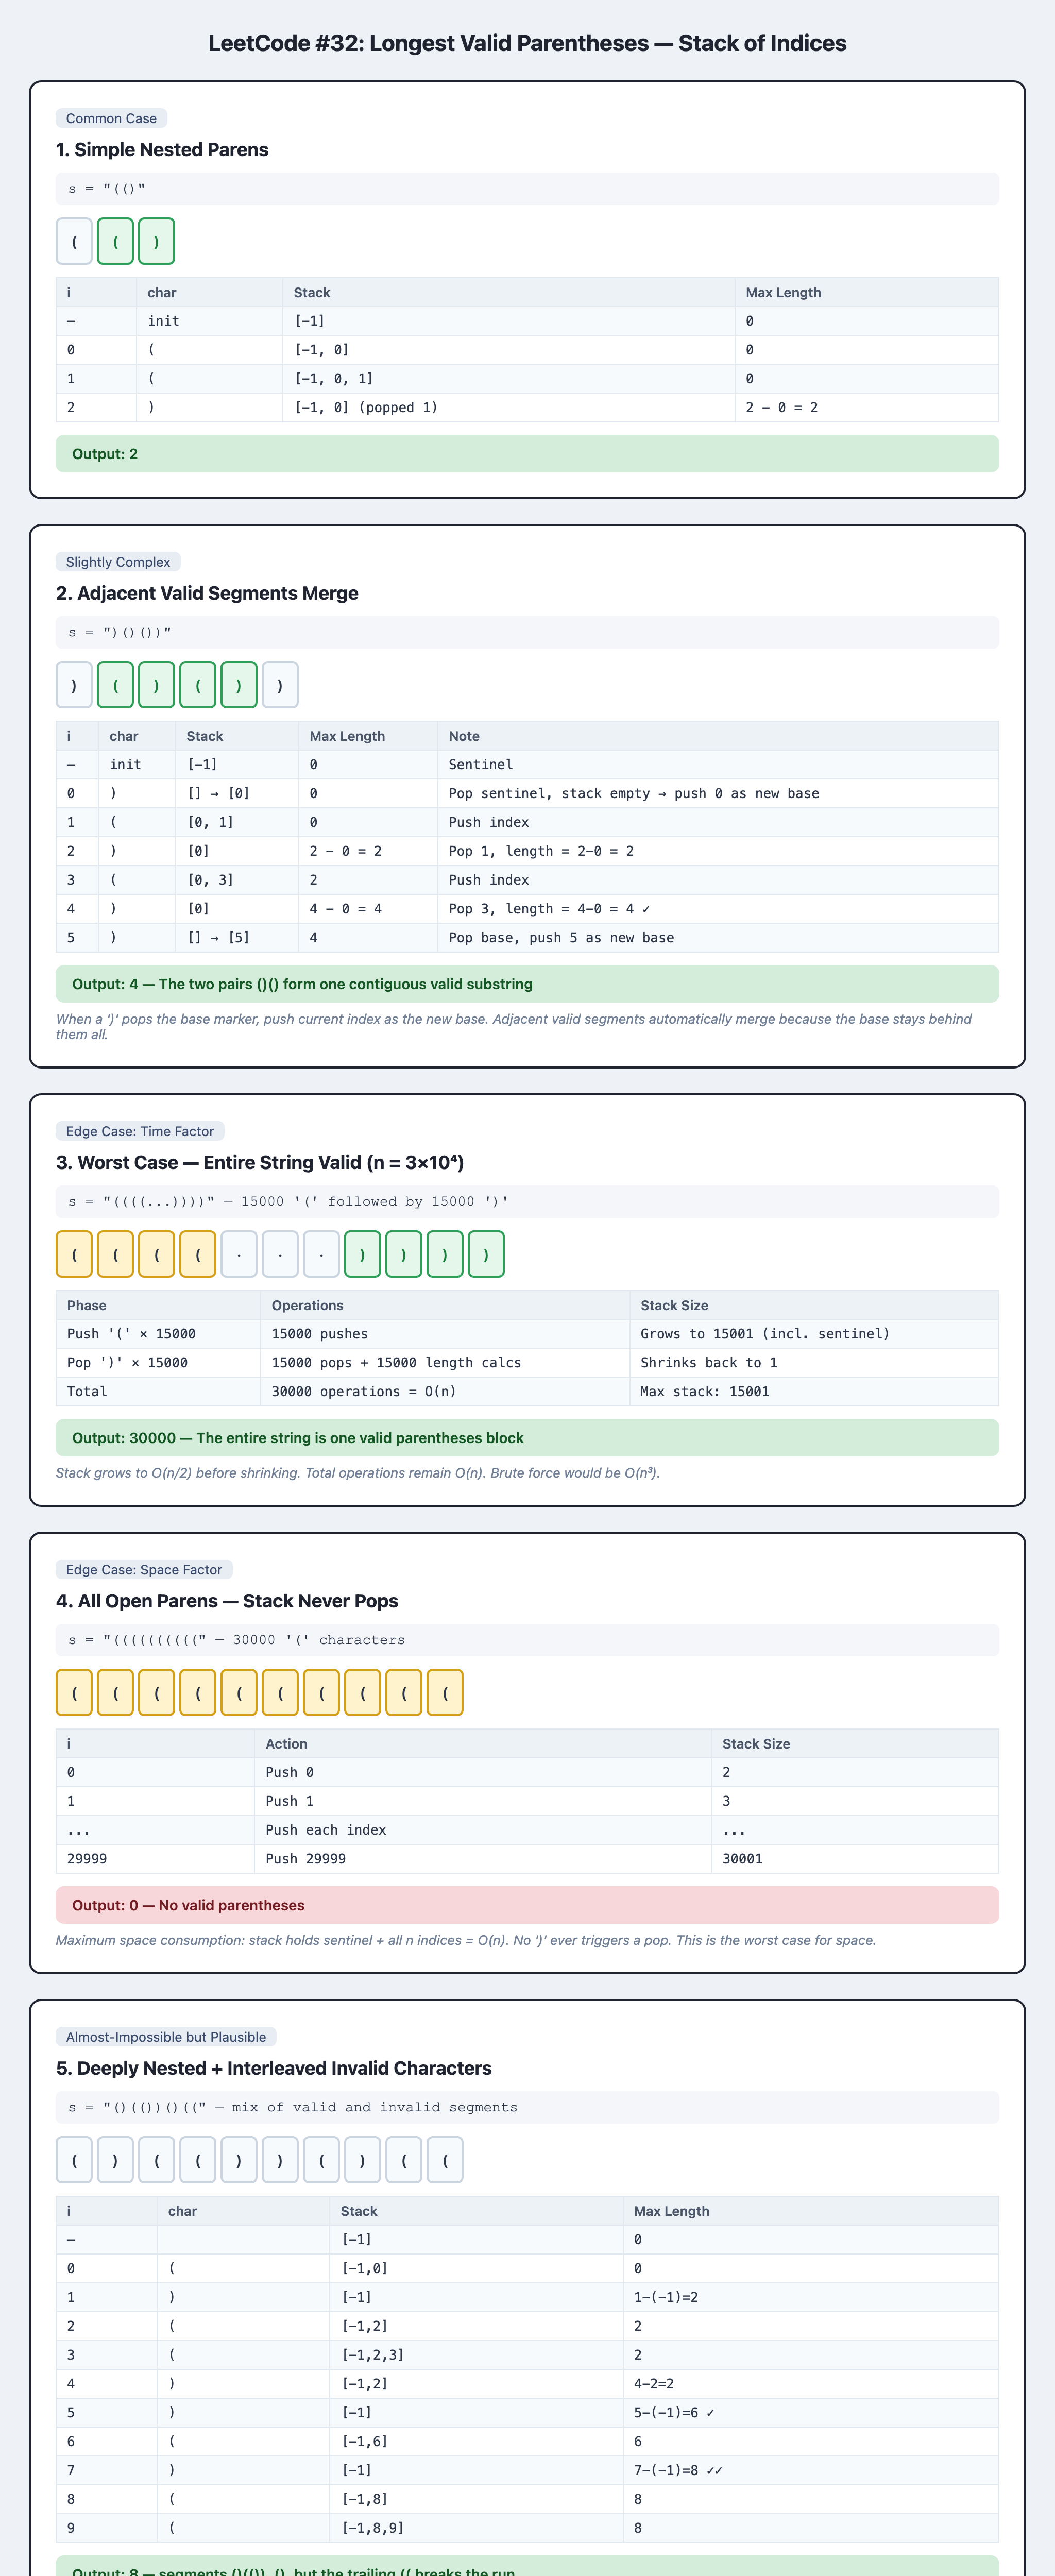